# Retail SQL Intelligence Layer
### Customer Segmentation, Revenue Analysis & Win-Back Targeting
**Author:** Justine Michaella Adzormado  
**Dataset:** Online Retail II (UCI ML Repository)  
**Database:** PostgreSQL  

---

This notebook is the exploratory companion to the production `.sql` scripts.  
It loads the data, runs all key queries, and visualises results for business reporting.

**Contents:**
1. Setup & Data Loading
2. RFM Segmentation
3. Revenue Analysis
4. Churn Risk & Retention
5. Win-Back Targeting
6. Advanced Window Functions

## 1. Setup & Data Loading

In [1]:
# Install dependencies if needed
# !pip install pandas openpyxl sqlalchemy psycopg2-binary matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── DATABASE CONNECTION ───────────────────────────────────────────────────────
DB_USER     = 'postgres'
DB_PASSWORD = 'Jaymcbrown4444'  
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'retail_db'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

# Quick connection test
with engine.connect() as conn:
    count = conn.execute(text('SELECT COUNT(*) FROM transactions')).scalar()
print(f'Connected. Transactions in DB: {count:,}')

Connected. Transactions in DB: 805,549


In [ ]:
## 2. RFM Segmentation

In [4]:
rfm_query = """
WITH rfm_raw AS (
    SELECT
        customer_id,
        (SELECT MAX(invoicedate)::date  FROM transactions)
            - MAX(invoicedate)::date    AS recency_days,
        COUNT(DISTINCT invoice)         AS frequency,
        SUM(revenue)                    AS monetary
    FROM transactions
    GROUP BY customer_id
),
rfm_scores AS (
    SELECT *,
        NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency    ASC)  AS f_score,
        NTILE(5) OVER (ORDER BY monetary     ASC)  AS m_score
    FROM rfm_raw
)
SELECT *,
    (r_score + f_score + m_score) AS rfm_total,
    CASE
        WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champion'
        WHEN r_score >= 3 AND m_score >= 4                  THEN 'Big Spender'
        WHEN r_score >= 3 AND f_score >= 3                  THEN 'Regular'
        WHEN r_score <= 2 AND f_score >= 3                  THEN 'At-Risk'
        WHEN r_score <= 2 AND f_score <= 2                  THEN 'Lost'
        ELSE 'Potential'
    END AS segment
FROM rfm_scores
ORDER BY rfm_total DESC;
"""

df_rfm = pd.read_sql(rfm_query, engine)
print(f'Customers segmented: {len(df_rfm):,}')
df_rfm.head(10)

Customers segmented: 5,878


,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_total,segment
0,17655,10,9,3652.48,5,5,5,15,Champion
1,12451,10,8,12669.88,5,5,5,15,Champion
2,13198,10,8,4974.23,5,5,5,15,Champion
3,13709,3,18,7591.75,5,5,5,15,Champion
4,15856,4,52,34220.34,5,5,5,15,Champion
5,17861,3,18,5127.69,5,5,5,15,Champion
6,15061,3,127,137818.52,5,5,5,15,Champion
7,12766,3,9,10068.28,5,5,5,15,Champion
8,13001,4,33,24172.10,5,5,5,15,Champion
9,14547,3,8,4007.54,5,5,5,15,Champion


             customer_count  total_revenue  avg_revenue
segment                                                
Champion               1292    12111085.18      9373.90
Big Spender             662     2399634.89      3624.83
At-Risk                 818     1748850.89      2137.96
Regular                 770      624951.97       811.63
Lost                   1534      554771.57       361.65
Potential               802      304134.66       379.22


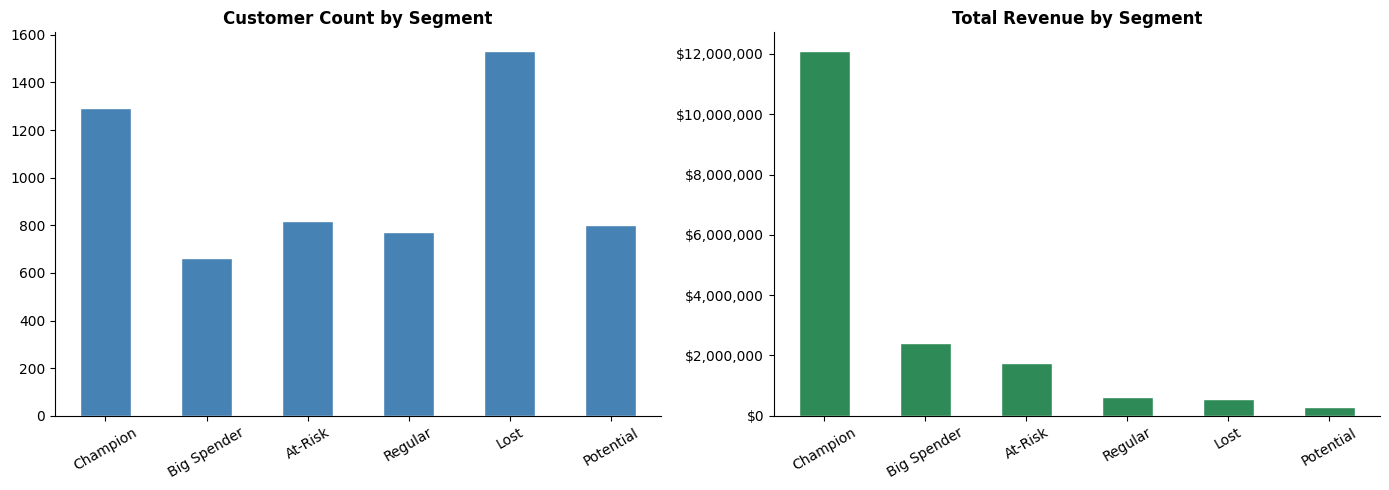

In [12]:
# Segment summary
seg_summary = df_rfm.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_revenue=('monetary', 'mean')
).round(2).sort_values('total_revenue', ascending=False)

print(seg_summary)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_summary['customer_count'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Customer Count by Segment', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

seg_summary['total_revenue'].plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='white'
)
axes[1].set_title('Total Revenue by Segment', fontweight='bold')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('rfm_segments.png')
plt.show()

## 3. Revenue Analysis

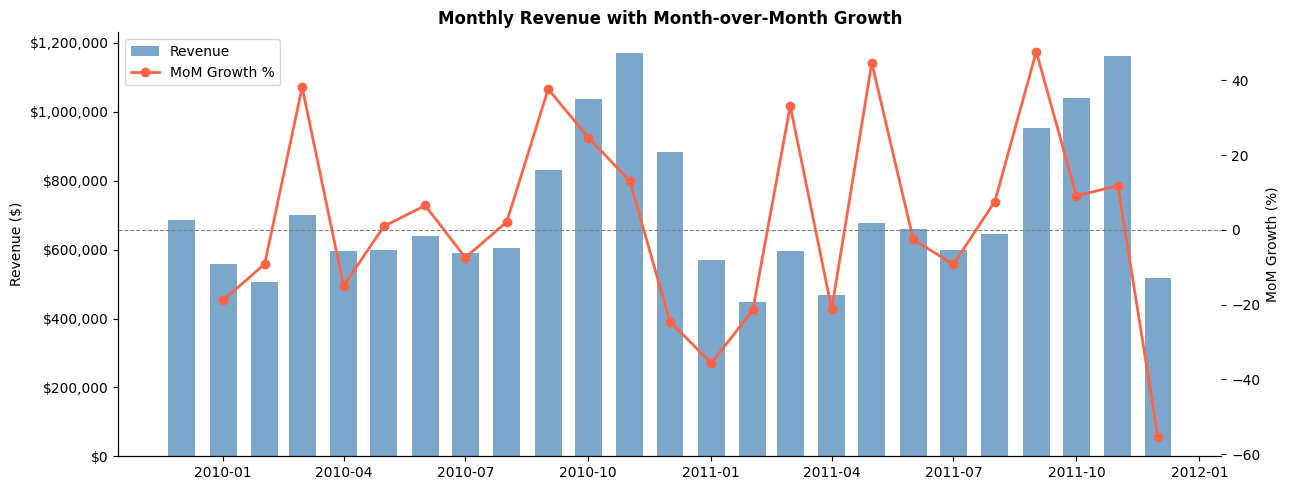

     month  total_revenue  mom_growth_pct
2009-12-01      686654.16             NaN
2010-01-01      557319.06          -18.84
2010-02-01      506371.06           -9.14
2010-03-01      699608.99           38.16
2010-04-01      594609.19          -15.01
2010-05-01      599985.79            0.90
2010-06-01      639066.58            6.51
2010-07-01      591636.74           -7.42
2010-08-01      604242.65            2.13
2010-09-01      831615.00           37.63
2010-10-01     1036680.00           24.66
2010-11-01     1172336.04           13.09
2010-12-01      884591.89          -24.54
2011-01-01      569445.04          -35.63
2011-02-01      447137.35          -21.48
2011-03-01      595500.76           33.18
2011-04-01      469200.36          -21.21
2011-05-01      678594.56           44.63
2011-06-01      661213.69           -2.56
2011-07-01      600091.01           -9.24
2011-08-01      645343.90            7.54
2011-09-01      952838.38           47.65
2011-10-01     1039318.79         

In [14]:
monthly_query = """
WITH monthly AS (
    SELECT
        DATE_TRUNC('month', invoicedate)::date AS month,
        ROUND(SUM(revenue)::numeric, 2)         AS total_revenue,
        COUNT(DISTINCT customer_id)             AS unique_customers
    FROM transactions
    GROUP BY DATE_TRUNC('month', invoicedate)
)
SELECT *,
    LAG(total_revenue) OVER (ORDER BY month) AS prev_month,
    ROUND(
        100.0 * (total_revenue - LAG(total_revenue) OVER (ORDER BY month))
              / NULLIF(LAG(total_revenue) OVER (ORDER BY month), 0), 2
    ) AS mom_growth_pct
FROM monthly
ORDER BY month;
"""

df_monthly = pd.read_sql(monthly_query, engine)
df_monthly['month'] = pd.to_datetime(df_monthly['month'])

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(df_monthly['month'], df_monthly['total_revenue'],
        width=20, color='steelblue', alpha=0.7, label='Revenue')
ax2.plot(df_monthly['month'], df_monthly['mom_growth_pct'],
         color='tomato', marker='o', linewidth=2, label='MoM Growth %')

ax1.set_title('Monthly Revenue with Month-over-Month Growth', fontweight='bold')
ax1.set_ylabel('Revenue ($)')
ax2.set_ylabel('MoM Growth (%)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.axhline(0, color='grey', linestyle='--', linewidth=0.8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('monthly_revenue.png')
plt.show()
print(df_monthly[['month','total_revenue','mom_growth_pct']].to_string(index=False))

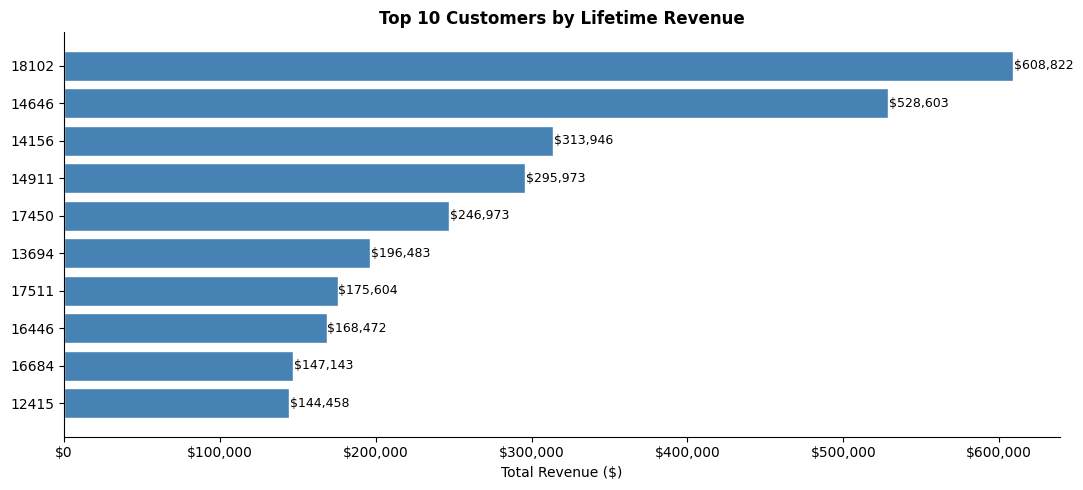

In [15]:
# Top 10 customers
top_customers_query = """
SELECT
    RANK() OVER (ORDER BY SUM(revenue) DESC) AS rank,
    customer_id,
    COUNT(DISTINCT invoice)                  AS total_orders,
    ROUND(SUM(revenue)::numeric, 2)          AS total_revenue,
    ROUND(AVG(revenue)::numeric, 2)          AS avg_order_value
FROM transactions
GROUP BY customer_id
ORDER BY total_revenue DESC
LIMIT 10;
"""
df_top_customers = pd.read_sql(top_customers_query, engine)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    df_top_customers['customer_id'].astype(str),
    df_top_customers['total_revenue'],
    color='steelblue', edgecolor='white'
)
ax.invert_yaxis()
ax.set_title('Top 10 Customers by Lifetime Revenue', fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, df_top_customers['total_revenue']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_customers.png')
plt.show()

## 4. Churn Risk & Retention

  churn_risk  customer_count  revenue_at_stake  avg_ltv
0     Active            1628       11193054.09  6875.34
1      Watch             748        2020775.02  2701.57
2    At-Risk             513        1060841.48  2067.92
3    Churned            2989        3468758.57  1160.51


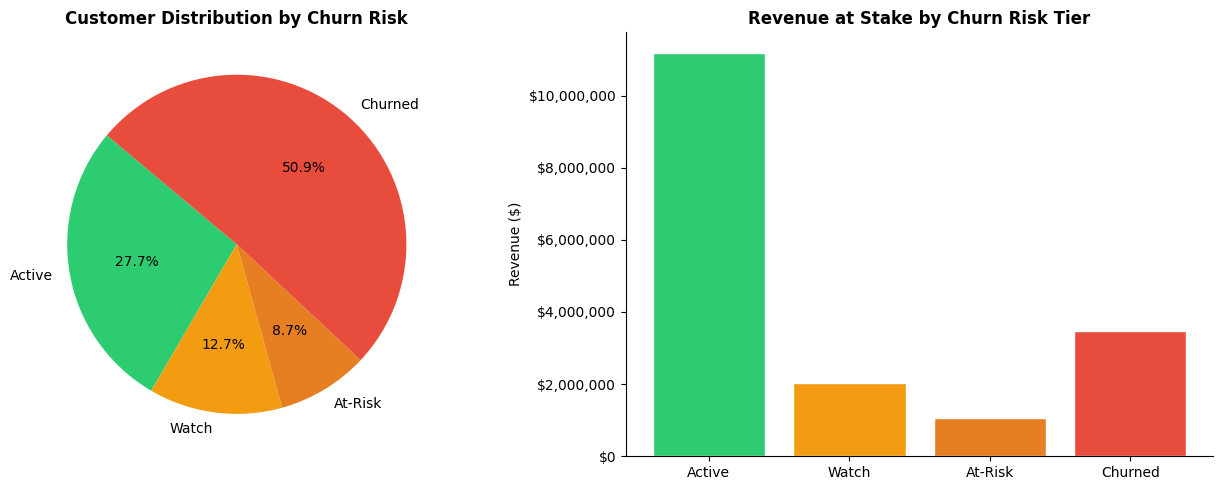

In [18]:
churn_query = """
WITH last_seen AS (
    SELECT
        customer_id,
        (SELECT MAX(invoicedate)::date FROM transactions)
            - MAX(invoicedate)::date   AS days_inactive,
        SUM(revenue)                    AS lifetime_value
    FROM transactions
    GROUP BY customer_id
),
churn_summary AS (
    SELECT
        CASE
            WHEN days_inactive < 30  THEN 'Active'
            WHEN days_inactive < 60  THEN 'Watch'
            WHEN days_inactive < 90  THEN 'At-Risk'
            ELSE 'Churned'
        END AS churn_risk,
        COUNT(customer_id)                          AS customer_count,
        ROUND(SUM(lifetime_value)::numeric, 2)      AS revenue_at_stake,
        ROUND(AVG(lifetime_value)::numeric, 2)      AS avg_ltv
    FROM last_seen
    GROUP BY churn_risk
)
SELECT *
FROM churn_summary
ORDER BY
    CASE churn_risk
        WHEN 'Active'  THEN 1
        WHEN 'Watch'   THEN 2
        WHEN 'At-Risk' THEN 3
        WHEN 'Churned' THEN 4
    END;

"""
df_churn = pd.read_sql(churn_query, engine)
print(df_churn)

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(df_churn['customer_count'], labels=df_churn['churn_risk'],
            colors=colors, autopct='%1.1f%%', startangle=140)
axes[0].set_title('Customer Distribution by Churn Risk', fontweight='bold')

axes[1].bar(df_churn['churn_risk'], df_churn['revenue_at_stake'],
            color=colors, edgecolor='white')
axes[1].set_title('Revenue at Stake by Churn Risk Tier', fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('churn_risk.png')
plt.show()

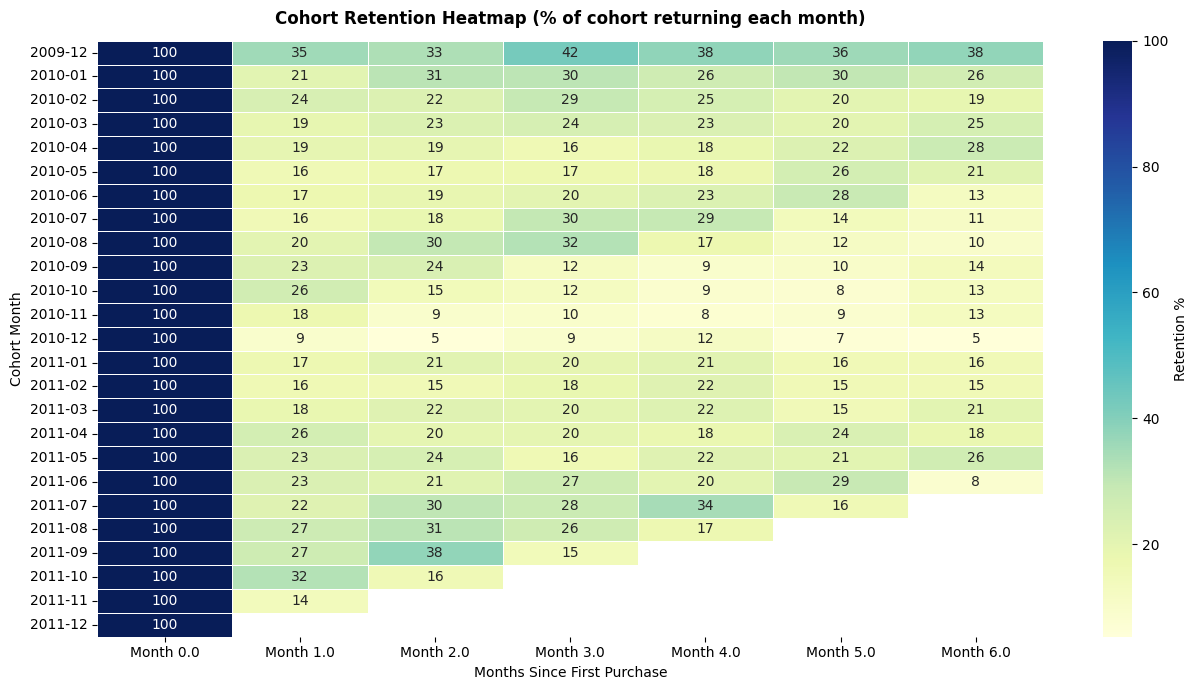

In [21]:
# Cohort retention heatmap
cohort_query = """
WITH first_purchase AS (
    SELECT customer_id,
           DATE_TRUNC('month', MIN(invoicedate))::date AS cohort_month
    FROM transactions GROUP BY customer_id
),
activity AS (
    SELECT t.customer_id, fp.cohort_month,
           (DATE_PART('year',  DATE_TRUNC('month', t.invoicedate))
             - DATE_PART('year',  fp.cohort_month)) * 12
           + DATE_PART('month', DATE_TRUNC('month', t.invoicedate))
             - DATE_PART('month', fp.cohort_month)  AS month_number
    FROM transactions t JOIN first_purchase fp ON t.customer_id = fp.customer_id
),
cohort_size AS (
    SELECT cohort_month, COUNT(DISTINCT customer_id) AS cohort_customers
    FROM first_purchase GROUP BY cohort_month
)
SELECT ca.cohort_month, ca.month_number,
       ROUND(100.0 * COUNT(DISTINCT ca.customer_id) / cs.cohort_customers, 1) AS retention_pct
FROM activity ca
JOIN cohort_size cs ON ca.cohort_month = cs.cohort_month
WHERE ca.month_number BETWEEN 0 AND 6
GROUP BY ca.cohort_month, cs.cohort_customers, ca.month_number
ORDER BY ca.cohort_month, ca.month_number;
"""
df_cohort = pd.read_sql(cohort_query, engine)
cohort_pivot = df_cohort.pivot(
    index='cohort_month', columns='month_number', values='retention_pct'
)
cohort_pivot.index = cohort_pivot.index.astype(str).str[:7]
cohort_pivot.columns = [f'Month {c}' for c in cohort_pivot.columns]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(cohort_pivot, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Retention %'})
ax.set_title('Cohort Retention Heatmap (% of cohort returning each month)',
             fontweight='bold', pad=12)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('cohort_retention.png')
plt.show()

## 5. Win-Back Targeting

In [22]:
recovery_query = """
WITH churned AS (
    SELECT customer_id, AVG(revenue) AS avg_order_value
    FROM transactions
    GROUP BY customer_id
    HAVING (SELECT MAX(invoicedate)::date FROM transactions)
               - MAX(invoicedate)::date > 90
)
SELECT
    COUNT(customer_id)                                              AS churned_customers,
    ROUND(AVG(avg_order_value)::numeric, 2)                         AS avg_order_value,
    ROUND(COUNT(*) * AVG(avg_order_value) * 0.10, 2)               AS recovery_10_pct,
    ROUND(COUNT(*) * AVG(avg_order_value) * 0.20, 2)               AS recovery_20_pct,
    ROUND(COUNT(*) * AVG(avg_order_value) * 0.30, 2)               AS recovery_30_pct
FROM churned;
"""
df_recovery = pd.read_sql(recovery_query, engine)
print('Revenue Recovery Potential from Churned Customers:')
print(df_recovery.T.rename(columns={0: 'Value'}))

Revenue Recovery Potential from Churned Customers:
                      Value
churned_customers   2989.00
avg_order_value       46.97
recovery_10_pct    14038.98
recovery_20_pct    28077.96
recovery_30_pct    42116.93


## 6. Advanced Window Functions Demo

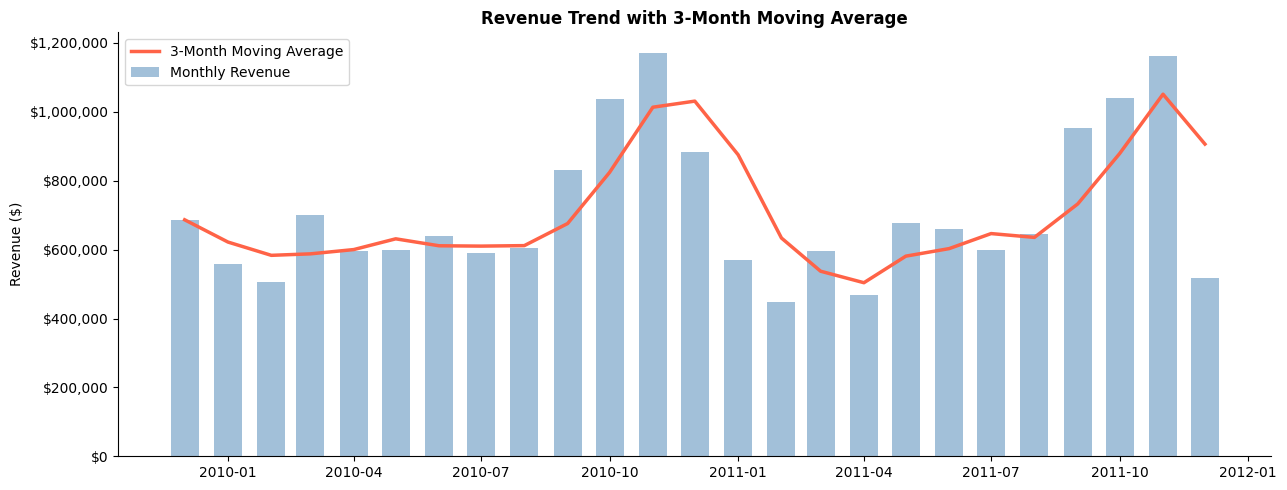

In [24]:
# 3-Month Moving Average Revenue
moving_avg_query = """
WITH monthly AS (
    SELECT DATE_TRUNC('month', invoicedate)::date AS month,
           ROUND(SUM(revenue)::numeric, 2)         AS revenue
    FROM transactions GROUP BY DATE_TRUNC('month', invoicedate)
)
SELECT month, revenue,
    ROUND(AVG(revenue) OVER (
        ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    )::numeric, 2) AS moving_avg_3m
FROM monthly ORDER BY month;
"""
df_ma = pd.read_sql(moving_avg_query, engine)
df_ma['month'] = pd.to_datetime(df_ma['month'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(df_ma['month'], df_ma['revenue'],
       width=20, color='steelblue', alpha=0.5, label='Monthly Revenue')
ax.plot(df_ma['month'], df_ma['moving_avg_3m'],
        color='tomato', linewidth=2.5, label='3-Month Moving Average')
ax.set_title('Revenue Trend with 3-Month Moving Average', fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('moving_average.png')
plt.show()

In [ ]:
# LTV Percentile Distribution
ltv_query = """
WITH customer_ltv AS (
    SELECT customer_id, ROUND(SUM(revenue)::numeric, 2) AS lifetime_value
    FROM transactions GROUP BY customer_id
)
SELECT customer_id, lifetime_value,
    NTILE(100) OVER (ORDER BY lifetime_value ASC) AS ltv_percentile
FROM customer_ltv ORDER BY lifetime_value DESC;
"""
df_ltv = pd.read_sql(ltv_query, engine)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_ltv['lifetime_value'], bins=60, color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(df_ltv['lifetime_value'].quantile(0.9),
           color='tomato', linestyle='--', linewidth=1.5,
           label=f"Top 10% threshold: ${df_ltv['lifetime_value'].quantile(0.9):,.0f}")
ax.set_title('Customer Lifetime Value Distribution', fontweight='bold')
ax.set_xlabel('Lifetime Value ($)')
ax.set_ylabel('Number of Customers')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('outputs/ltv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

This notebook demonstrated:
- **RFM Segmentation** using `NTILE` window functions across recency, frequency, and monetary dimensions
- **Revenue Intelligence** including month-over-month growth with `LAG` and cumulative totals
- **Churn Risk Tiering** using conditional `CASE` logic and inactive day calculations
- **Cohort Retention Analysis** tracking customer return rates month by month
- **Win-Back Revenue Modelling** estimating recovery potential at 10/20/30% conversion
- **Advanced Window Functions** including `RANK`, `DENSE_RANK`, `NTILE`, `LAG`, `LEAD`, moving averages, and `FIRST_VALUE`/`LAST_VALUE`

All production queries are available as standalone `.sql` files in the `/sql` directory.